In [0]:
%pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 19.9 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install "gymnasium[toy-text]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 124.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [0]:
env = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False)

In [0]:
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 2000

In [0]:
# Q-Table
state_space = env.observation_space.n
action_space = env.action_space.n
q_table = np.zeros((state_space, action_space))

rewards_all_episodes = []

In [0]:
# Agent Training
for episodes in range(episodes):
    state, info = env.reset()
    done = False
    truncated = False
    rewards_current_episode = 0

    while not (done or truncated):
        # Epsilon-Greedy: Radom Explore vs Exploit
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state, :])
        
        new_state, reward, done, truncated, info = env.step(action)

        q_table[state, action] = q_table[state, action] + alpha * (reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action])
        
        state = new_state
        rewards_current_episode += reward
    
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_all_episodes.append(rewards_current_episode)

print("Completed")

Completed


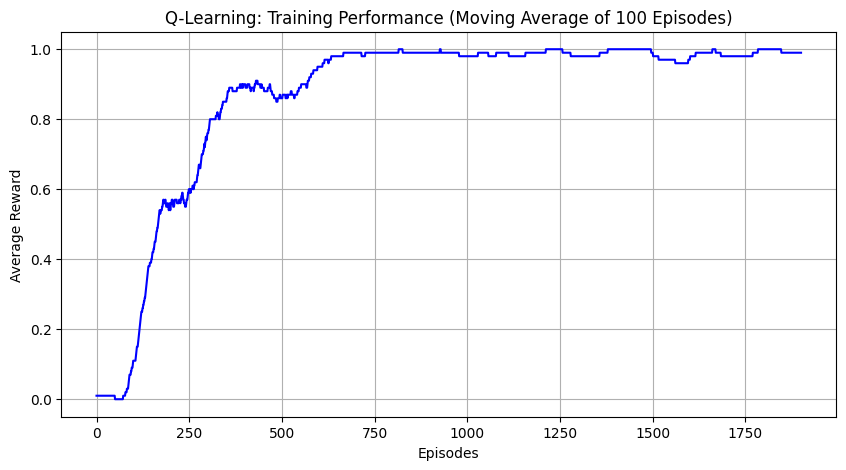

In [0]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_rewards = moving_average(rewards_all_episodes, window_size=100)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_rewards, color='blue')
plt.title('Q-Learning: Training Performance (Moving Average of 100 Episodes)')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.grid(True)
plt.show()

In [0]:
# Testing
test_env = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False, render_mode='human')
state, info = test_env.reset()
done = False
truncated = False

step_count = 0

while not (done or truncated) and step_count < 20:
    # Choose the best action from Q-Table
    action = np.argmax(q_table[state, :])
    state, reward, done, truncated, info = test_env.step(action)
    step_count += 1

if reward == 1.0:
    print("Completed at {step_count} steps")
else:
    print("Failed")

test_env.close()

print("\nFinal Q-Table:")
print(q_table)

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


Completed at {step_count} steps

Final Q-Table:
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.50950689 0.6889727 ]
 [0.6927506  0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.90249998 0.         0.42458908]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.85737427]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9022112  0.95       0.85732013]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]
